<a href="https://colab.research.google.com/github/andrebellu/Pokedex/blob/main/PokedexNotebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<font size = 7><center>POKÈDEX</center></font>

<div align="center">
  <img src="https://i.ibb.co/LYW6YQ9/pngegg-1.png" width="500"/>
</div>



<center><font size = 6>Notebook che permette all'utente di utilizzare un semplice Pokèdex che permette di visualizzare i Pokèmon da id: 1 all'id: 809 e di confrontare le loro statistiche</center></font>

# Preparazione
Sezione le cui celle contengono del codice per soddisfare dei prerequisiti per la buona riuscita del progetto

### Import delle librerie

In [1]:
from IPython.display import display, Image
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import plotly.offline as pyo
import IPython
import requests
import shutil
import glob
import re
import os

### Import del [dataset](https://raw.githubusercontent.com/fanzeyi/pokemon.json/master/pokedex.json)

In [2]:
d = requests.get("https://raw.githubusercontent.com/fanzeyi/pokemon.json/master/pokedex.json")
data = d.json()

### Clone della mia repository su [GitHub](https://github.com/andrebellu/PokemonImages)
Inoltre in questa cella copio i file in un'altra cartella per poi rinominarli nella cella successiva

In [3]:
!git clone https://github.com/andrebellu/PokemonImages
shutil.copytree("/content/PokemonImages/pokemon/pokemonpng", "/content/RenamedPokemonImages")

Cloning into 'PokemonImages'...
remote: Enumerating objects: 834, done.
remote: Counting objects: 100% (834/834), done.
remote: Compressing objects: 100% (831/831), done.
remote: Total 834 (delta 2), reused 822 (delta 0), pack-reused 0
Receiving objects: 100% (834/834), 39.51 MiB | 41.12 MiB/s, done.
Resolving deltas: 100% (2/2), done.


'/content/RenamedPokemonImages'

In [4]:
pkifolder = "/content/RenamedPokemonImages"
folder_2 = "/content/PokemonImages/pokemon/pokemonpng"

for count, filename in enumerate(os.listdir(pkifolder)):
        dst = re.sub("\D", "", filename) + ".png"
        src = pkifolder + "/" + filename
        dst = pkifolder + "/" + dst
        
        os.rename(src, dst)

# Esecuzione

### Chiedo all'utente di inserire un numero, corrispondente all'[id del pokèmon](https://bulbapedia.bulbagarden.net/wiki/List_of_Pok%C3%A9mon_by_National_Pok%C3%A9dex_number)

In [5]:
i = input("Inserisci l'id del Pokèmon da cercare: ")

Inserisci l'id del Pokèmon da cercare: 386


### Cerco nel dataset l'id datomi in input dall'utente e stampo le caratteristiche del pokèmon

In [6]:
pokemon1 = []
pokemon2 = []
list_words = []

for element in data:
  if str(element["id"]) == i:
    print("Name: " , end="")
    print(element["name"]["english"] + ", " + element["name"]["japanese"])

    name = element["name"]["english"]
    
    print("Type: " , end="")
    print(re.sub("[^.,a-zA-Z0-9 \n\.]", "", str(element["type"])))

    print("HP: ", end="")
    print(element["base"]["HP"])

    print("Attack: ", end="")
    print(element["base"]["Attack"])

    print("Defense: ", end="")
    print(element["base"]["Defense"])

    print("Sp. Attack: ", end="")
    print(element["base"]["Sp. Attack"])

    print("Sp. Defense: ", end="")
    print(element["base"]["Sp. Defense"])
    
    print("Speed: ", end="")
    print(element["base"]["Speed"])

    pokemon1.extend([element["base"]["HP"], element["base"]["Attack"], element["base"]["Defense"], element["base"]["Sp. Attack"], element["base"]["Sp. Defense"], element["base"]["Speed"]])

Name: Deoxys, デオキシス
Type: Psychic
HP: 50
Attack: 150
Defense: 50
Sp. Attack: 150
Sp. Defense: 50
Speed: 150


### Cerco tramite i filename delle immagini se ho pokèmon di diverse forme

In [7]:
files = os.listdir("/content/PokemonImages/pokemon/pokemonpng")

for element in files:
  if "-" in element:
    list_words.append(re.sub("[0-9]", "", element))

list_words = list(set(list_words))

### Display dell'immagine del pokèmon
Tramite un url che viene modificato in base all'id cerco nella cartella /content/RenamedPokemonImages l'immagine del pokemon desiderato e la stampo

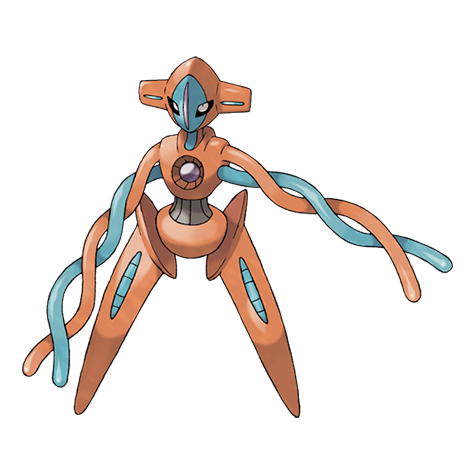

In [8]:
url = folder_2 + "/%s.png" % (i)
IPython.display.Image(url, width = 250)

### Controllo per eventuali forme diverse del pokèmon

In [9]:
pokemon_variations = []

for x in list_words:
  for y in files:
    if str(i)+x == y:
      pokemon_variations.append(y)

### Display di tutte le immagini di tutte le forme disponibili

Tutte le "forme" di Deoxys


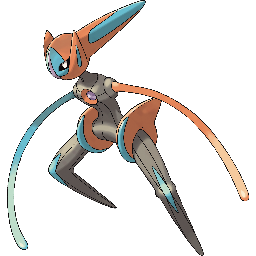

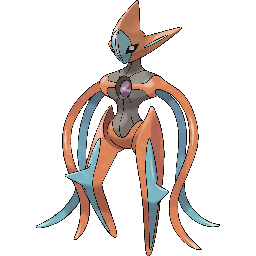

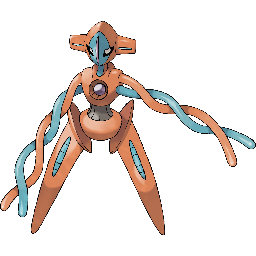

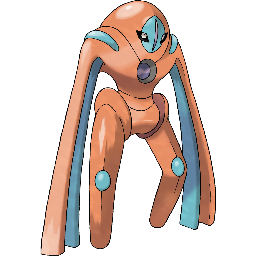

In [10]:
print(f"Tutte le \"forme\" di {name}")
for element in pokemon_variations:
    img = Image("/content/PokemonImages/pokemon/pokemonpng/%s" % element)
    display(img)

### Chiedo all'utente di inserire un secondo numero 

In [11]:
i_2 = input("Inserisci l'id del secondo pokèmon da confrontare: ")

Inserisci l'id del secondo pokèmon da confrontare: 25


### Ripeto le stesse operazioni ma con il secondo id

In [12]:
for ele in data:
  if str(ele["id"]) == i_2:
    print("Name: " , end="")
    print(ele["name"]["english"] + ", " + ele["name"]["japanese"])

    name_2 = ele["name"]["english"]
    
    print("Type: " , end="")
    print(re.sub("[^.,a-zA-Z0-9 \n\.]", "", str(ele["type"])))

    print("HP: ", end="")
    print(ele["base"]["HP"])

    print("Attack: ", end="")
    print(ele["base"]["Attack"])

    print("Defense: ", end="")
    print(ele["base"]["Defense"])

    print("Sp. Attack: ", end="")
    print(ele["base"]["Sp. Attack"])

    print("Sp. Defense: ", end="")
    print(ele["base"]["Sp. Defense"])
    
    print("Speed: ", end="")
    print(ele["base"]["Speed"])
    pokemon2.extend([ele["base"]["HP"], ele["base"]["Attack"], ele["base"]["Defense"], ele["base"]["Sp. Attack"], ele["base"]["Sp. Defense"], ele["base"]["Speed"]])

Name: Pikachu, ピカチュウ
Type: Electric
HP: 35
Attack: 55
Defense: 40
Sp. Attack: 50
Sp. Defense: 50
Speed: 90


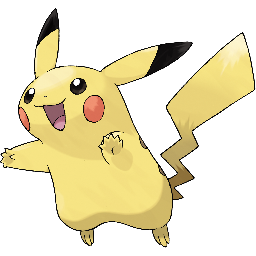

In [17]:
url = folder_2 + "/%s.png" % (i_2)
IPython.display.Image(url, width = 250)

In [14]:
pokemon_variations = []

for x in list_words:
  for y in files:
    if str(i_2)+x == y:
      pokemon_variations.append(y)

Tutte le "forme" di Pikachu


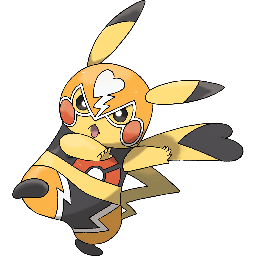

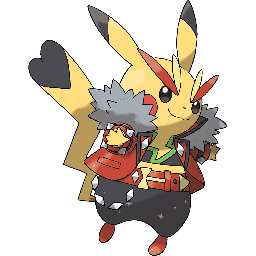

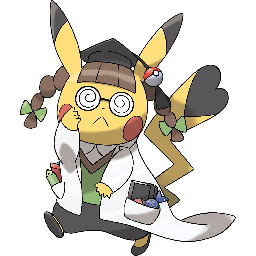

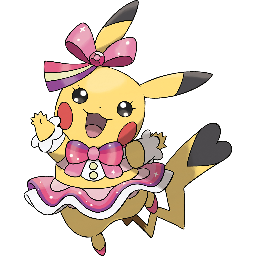

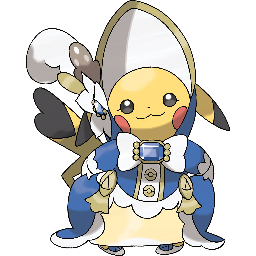

In [15]:
print(f"Tutte le \"forme\" di {name_2}")
for element in pokemon_variations:
    img = Image("/content/PokemonImages/pokemon/pokemonpng/%s" % element)
    display(img)

# Conclusione confrontando in un grafico radar le caratteristiche dei due pokèmon

In [16]:
categories = ['HP', 'Attack', 'Defense', 'Sp. Attack', 'Sp. Defense', 'Speed']

fig = go.Figure(
    data=[
        go.Scatterpolar(r=pokemon1, theta=categories, fill='toself', name=name),
        go.Scatterpolar(r=pokemon2, theta=categories, fill='toself', name=name_2),
    ],
    layout=go.Layout(
        title=go.layout.Title(text=f'Confronto tra {name} e {name_2}'),
        polar={'radialaxis': {'visible': True}},
        showlegend=True
    )
)

fig.update_layout(
    autosize=False,
    width=800,
    height=800,
    title_x=0.5,
    )

pyo.iplot(fig)